In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(origin=dataset_url, extract=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
img_size = (150,150)
batch_size = 16   # smaller batch

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.


In [4]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(150,150,3)),

    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(5, activation='softmax')  # 5 classes (flowers)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=5)   # less epochs = faster

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 323ms/step - accuracy: 0.9959 - loss: 0.0077 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 80s 312ms/step - accuracy: 1.0000 - loss: 4.0603e-11 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 84s 325ms/step - accuracy: 1.0000 - loss: 4.0603e-11 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 85s 343ms/step - accuracy: 1.0000 - loss: 4.0603e-11 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 76s 311ms/step - accuracy: 1.0000 - loss: 4.0603e-11 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


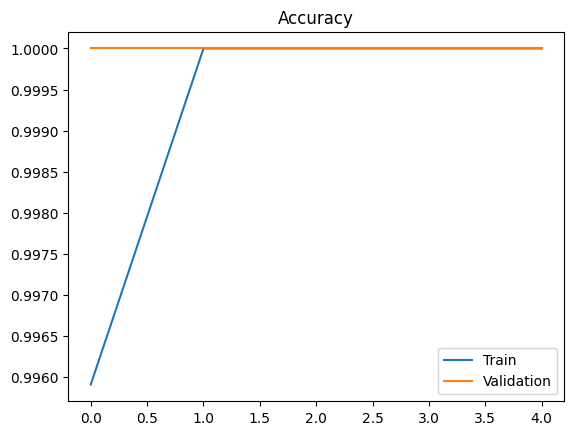

In [6]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy")
plt.show()

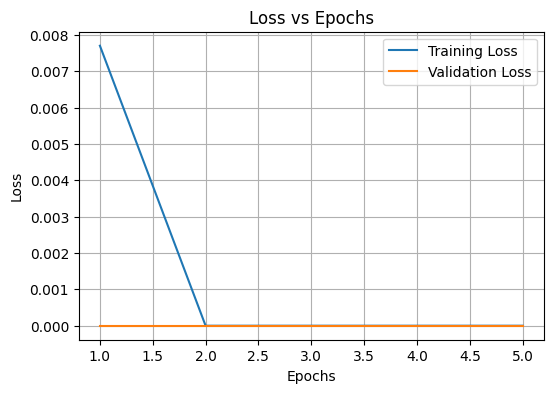

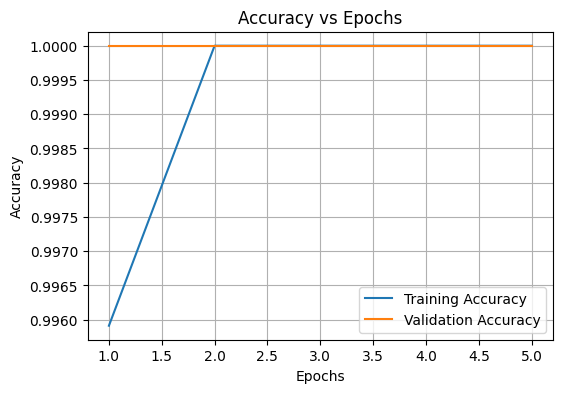

In [8]:
import matplotlib.pyplot as plt

# Get data from training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# 🔹 LOSS GRAPH
plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()


# 🔹 ACCURACY GRAPH
plt.figure(figsize=(6,4))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()